In [6]:
from pathlib import Path
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [7]:
project_root = Path.cwd()
if not (project_root / "Data" / "processed" / "ltv_dataset.csv").exists():
    project_root = Path("..")

csv_path = project_root / "Data" / "processed" / "ltv_dataset.csv"
df = pd.read_csv(csv_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn,LTV
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Month-to-month,29.85,29.85,No,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,One year,56.95,1889.50,No,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Month-to-month,53.85,108.15,Yes,107.70
3,7795-CFOCW,Male,0,No,No,45,No,DSL,One year,42.30,1840.75,No,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,70.70,151.65,Yes,141.40


In [8]:
model_path = project_root / "models" / "ltv_model.pkl"
model = joblib.load(model_path)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'Churn']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset 

In [11]:
#Create Customer Segments

if "Predicted_LTV" not in df.columns:
    if "LTV" in df.columns:
        df["Predicted_LTV"] = df["LTV"].astype(float)
    else:
        raise KeyError("No LTV or Predicted_LTV column found in the dataset.")

# Create four customer value segments based on predicted LTV.
df["Customer_Segment"] = pd.qcut(
    df["Predicted_LTV"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Premium Value"
    ]
)

#View the results.
df[["customerID", "Predicted_LTV", "Customer_Segment"]].head(10)

,customerID,Predicted_LTV,Customer_Segment
0,7590-VHVEG,29.85,Low Value
1,5575-GNVDE,1936.30,High Value
2,3668-QPYBK,107.70,Low Value
3,7795-CFOCW,1903.50,High Value
4,9237-HQITU,141.40,Low Value
5,9305-CDSKC,797.20,Medium Value
6,1452-KIOVK,1960.20,High Value
7,6713-OKOMC,297.50,Low Value
8,7892-POOKP,2934.40,High Value
9,6388-TABGU,3481.30,High Value


In [12]:
#Identify High-Value Customers

#Filter the highest-value customers.
high_value_customers = df[
    df["Customer_Segment"] == "Premium Value"
]

high_value_customers.head()

#Count them.
print("Number of Premium Customers:")
print(len(high_value_customers))

Number of Premium Customers:
1758


In [13]:
#Display the top 10 customers by predicted LTV.
top_customers = df.sort_values(
    by="Predicted_LTV",
    ascending=False
)

top_customers[
    [
        "customerID",
        "Predicted_LTV",
        "Customer_Segment"
    ]
].head(10)

,customerID,Predicted_LTV,Customer_Segment
4578,7569-NMZYQ,8550.00,Premium Value
6109,9924-JPRMC,8510.40,Premium Value
4602,2889-FPWRM,8481.60,Premium Value
3200,3810-DVDQQ,8467.20,Premium Value
6757,9739-JLPQJ,8460.00,Premium Value
4148,6904-JLBGY,8449.20,Premium Value
2363,6650-BWFRT,8434.80,Premium Value
2110,8984-HPEMB,8424.15,Premium Value
5338,9788-HNGUT,8420.40,Premium Value
2020,1488-PBLJN,8413.20,Premium Value


In [14]:
#Count customers in each segment.

segment_counts = df["Customer_Segment"].value_counts()

segment_counts

Customer_Segment
Low Value        1759
High Value       1758
Premium Value    1758
Medium Value     1757
Name: count, dtype: int64

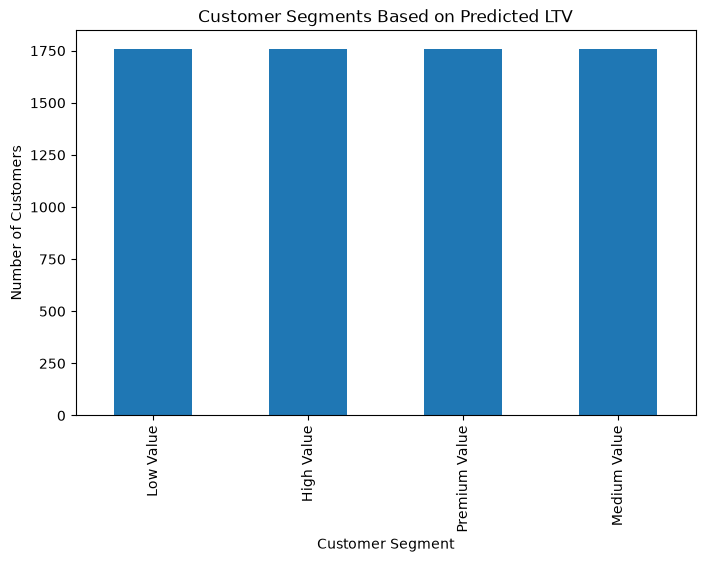

In [15]:
#Create a bar chart.

segment_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Segments Based on Predicted LTV")

plt.xlabel("Customer Segment")

plt.ylabel("Number of Customers")

plt.show()

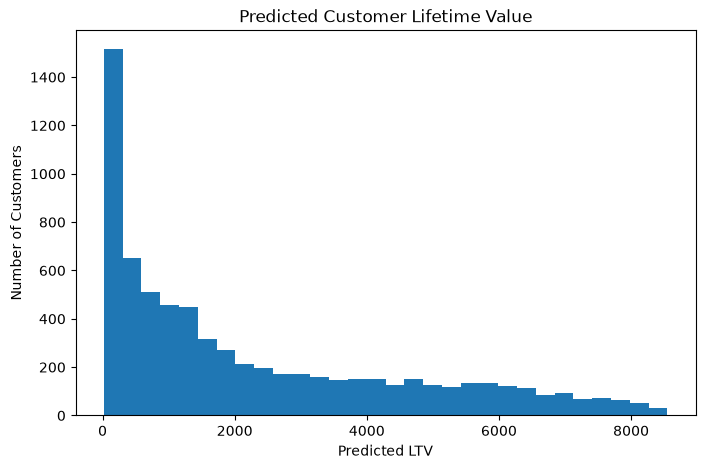

In [16]:
#Visualize Predicted LTV Distribution
plt.figure(figsize=(8,5))

plt.hist(df["Predicted_LTV"], bins=30)

plt.title("Predicted Customer Lifetime Value")

plt.xlabel("Predicted LTV")

plt.ylabel("Number of Customers")

plt.show()

In [17]:
output_path = project_root / "docs" / "customer_segments.csv"
df.to_csv(output_path, index=False)

In [ ]:
## Day 20 Conclusion

# The trained LTV model was used to predict Customer Lifetime Value for every customer.

# Customers were segmented into four groups:

# - Low Value
# - Medium Value
# - High Value
# - Premium Value

# The Premium Value customers represent the highest predicted lifetime revenue and are ideal candidates for loyalty programs, personalized offers, and retention strategies.